<a href="https://colab.research.google.com/github/rikharhm0208-coder/PROJECT_KOMPUTASI_KEUANGAN/blob/main/SIMULASI_TIAN_BINOMIAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

/tmp/ipykernel_744/2238633429.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2025-03-12", end="2026-03-12")
[*********************100%***********************]  1 of 1 completed


Volatility: 0.2876487679999588


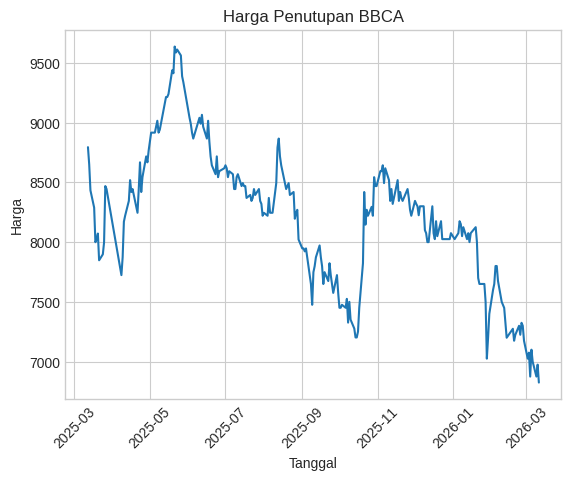

In [ ]:
# ==============================
# Ambil Data BBCA
# ==============================

ticker = "BBCA.JK"

data = yf.download(ticker, start="2025-03-12", end="2026-03-12")

# Jika kolom berbentuk MultiIndex
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

# Reset index supaya Date jadi kolom biasa
data = data.reset_index()

# Harga penutupan
prices = data['Close']

# ==============================
# Log Return
# ==============================

log_return = np.log(prices / prices.shift(1)).dropna()

# Volatility tahunan
volatility = log_return.std() * np.sqrt(252)

print("Volatility:", volatility)

# ==============================
# Plot Harga BBCA
# ==============================

plt.figure()
plt.plot(data['Date'], prices)
plt.title("Harga Penutupan BBCA")
plt.xlabel("Tanggal")
plt.ylabel("Harga")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# ==============================
# PARAMETER SIMULASI
# ==============================

T = 1          # horizon waktu (1 tahun)
L = 252        # jumlah langkah waktu (hari trading)
dt = T / L     # panjang interval waktu
S0 = prices.iloc[-1].item() # Harga awal simulasi

# ==============================
# Hitung Variansi log return
# ==============================
var_log = log_return.var()

# Estimasi sigma sesuai formula
sigma = (1/np.sqrt(dt)) * np.sqrt(var_log)

# ==============================
# Hitung mean log return
# ==============================
mean_log = log_return.mean()

# Estimasi mu sesuai formula
mu = (1/dt)*mean_log + 0.5*sigma**2

print("S0: ", S0)
print("mu: ", mu)
print("sigma: ", sigma)

S0:  6825.0
mu:  -0.23050107209861212
sigma:  0.28764876799995875


**BINOMIAL TREE**

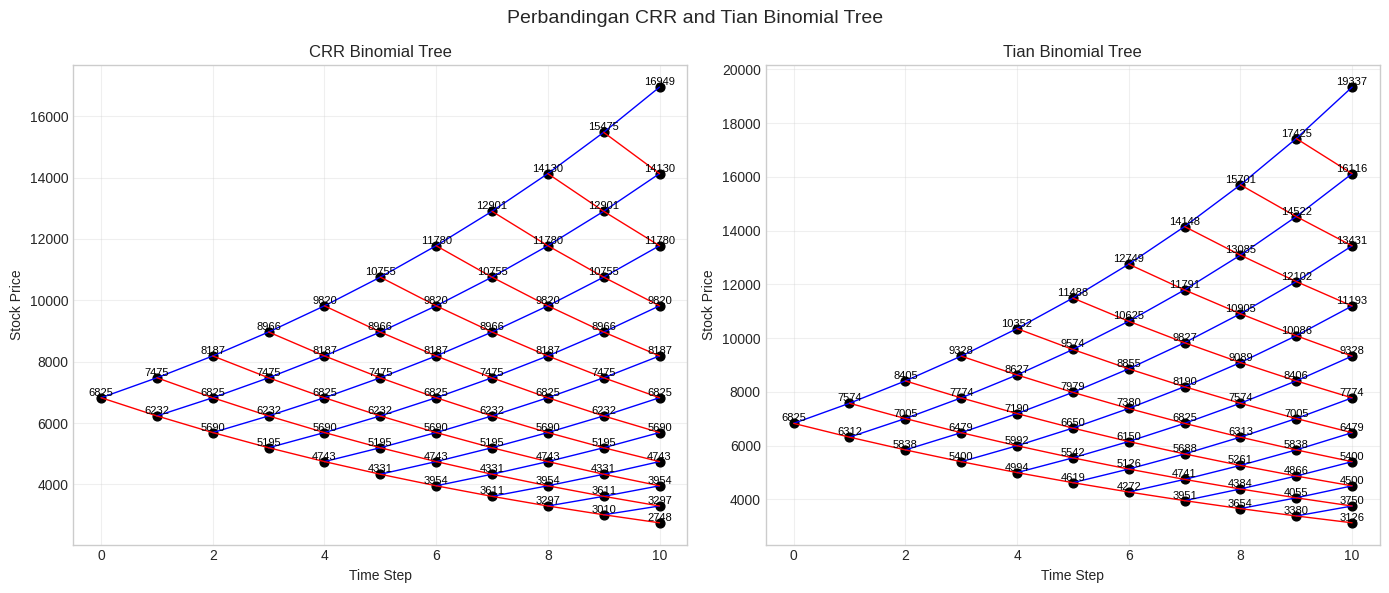

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

# ==============================
# PARAMETER
# ==============================

r = 0.0475
N_plot = 10
dt = T / N_plot

# ==============================
# CRR PARAMETER
# ==============================

u_crr = np.exp(sigma * np.sqrt(dt))
d_crr = np.exp(-sigma * np.sqrt(dt))

# ==============================
# TIAN PARAMETER
# ==============================

R = np.exp(r * dt)
V = np.exp(sigma**2 * dt)

u_tian = 0.5 * R * V * (V + 1 + np.sqrt(V**2 + 2*V - 3))
d_tian = 0.5 * R * V * (V + 1 - np.sqrt(V**2 + 2*V - 3))

# ==============================
# BUILD TREE FUNCTION
# ==============================

def build_tree(S0, u, d, N):

    tree = []

    for i in range(N + 1):

        level = []

        for j in range(i + 1):

            price = S0 * (u**j) * (d**(i-j))
            level.append(price)

        tree.append(level)

    return tree


tree_crr = build_tree(S0, u_crr, d_crr, N_plot)
tree_tian = build_tree(S0, u_tian, d_tian, N_plot)

# ==============================
# PLOT TREE FUNCTION
# ==============================

def plot_tree(ax, tree, u, d, title):

    for i in range(N_plot + 1):

        for j in range(i + 1):

            y = tree[i][j]

            # node
            ax.scatter(i, y, color="black", s=40)

            # angka harga
            ax.text(i,
                    y,
                    f"{y:.0f}",
                    fontsize=8,
                    ha="center",
                    va="bottom",
                    color="black")

            if i < N_plot:

                up = S0*(u**(j+1))*(d**(i-j))
                down = S0*(u**j)*(d**(i-j+1))

                # garis ke atas
                ax.plot([i, i+1],
                        [y, up],
                        color="blue",
                        linewidth=1)

                # garis ke bawah
                ax.plot([i, i+1],
                        [y, down],
                        color="red",
                        linewidth=1)

    ax.set_title(title)
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Stock Price")
    ax.grid(alpha=0.3)


# ==============================
# SUBPLOT
# ==============================

fig, ax = plt.subplots(1,2, figsize=(14,6))
plot_tree(ax[0], tree_crr, u_crr, d_crr, "CRR Binomial Tree")
plot_tree(ax[1], tree_tian, u_tian, d_tian, "Tian Binomial Tree")
plt.suptitle("Perbandingan CRR and Tian Binomial Tree", fontsize=14)
plt.tight_layout()
plt.show()

**HARGA OPSI**

In [ ]:
# =======================
# MODEL BLACK SCHOLES
# =======================

def black_scholes(S0, K, r, sigma, T, option="call"):

    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T)/(sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)

    if option == "call":
        price = S0*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    else:
        price = K*np.exp(-r*T)*norm.cdf(-d2) - S0*norm.cdf(-d1)

    return price


# =======================
# CRR BINOMIAL MODEL
# =======================

def CRR_option(S0, K, r, sigma, T, N, option="call", style="european"):

    dt = T/N

    u = np.exp(sigma*np.sqrt(dt))
    d = 1/u

    p = (np.exp(r*dt)-d)/(u-d)

    stock = np.zeros((N+1,N+1))
    option_val = np.zeros((N+1,N+1))

    for i in range(N+1):
        for j in range(i+1):
            stock[j,i] = S0*(u**(i-j))*(d**j)

    for j in range(N+1):
        if option == "call":
            option_val[j,N] = max(stock[j,N]-K,0)
        else:
            option_val[j,N] = max(K-stock[j,N],0)

    for i in range(N-1,-1,-1):
        for j in range(i+1):

            hold = np.exp(-r*dt)*(p*option_val[j,i+1] + (1-p)*option_val[j+1,i+1])

            if style == "american":

                if option == "call":
                    exercise = max(stock[j,i]-K,0)
                else:
                    exercise = max(K-stock[j,i],0)

                option_val[j,i] = max(hold,exercise)

            else:
                option_val[j,i] = hold

    return option_val[0,0]

# =======================
# TIAN BINOMIAL MODEL
# =======================

def Tian_option(S0, K, r, sigma, T, N, option="call", style="european"):

    dt = T/N

    R = np.exp(r*dt)
    V = np.exp(sigma**2*dt)

    u = 0.5*R*V*(V+1 + np.sqrt(V**2 + 2*V -3))
    d = 0.5*R*V*(V+1 - np.sqrt(V**2 + 2*V -3))

    p = (R-d)/(u-d)

    stock = np.zeros((N+1,N+1))
    option_val = np.zeros((N+1,N+1))

    for i in range(N+1):
        for j in range(i+1):
            stock[j,i] = S0*(u**(i-j))*(d**j)

    for j in range(N+1):

        if option == "call":
            option_val[j,N] = max(stock[j,N]-K,0)
        else:
            option_val[j,N] = max(K-stock[j,N],0)

    for i in range(N-1,-1,-1):
        for j in range(i+1):

            hold = np.exp(-r*dt)*(p*option_val[j,i+1] + (1-p)*option_val[j+1,i+1])

            if style == "american":

                if option == "call":
                    exercise = max(stock[j,i]-K,0)
                else:
                    exercise = max(K-stock[j,i],0)

                option_val[j,i] = max(hold,exercise)

            else:
                option_val[j,i] = hold

    return option_val[0,0]

K = 7000
N = 252

# Black-Scholes
bs_call = black_scholes(S0, K, r, sigma, T, "call")
bs_put = black_scholes(S0, K, r, sigma, T, "put")

# CRR
crr_call_e = CRR_option(S0,K,r,sigma,T,N,"call","european")
crr_put_e = CRR_option(S0,K,r,sigma,T,N,"put","european")

crr_call_a = CRR_option(S0,K,r,sigma,T,N,"call","american")
crr_put_a = CRR_option(S0,K,r,sigma,T,N,"put","american")

# Tian
tian_call_e = Tian_option(S0,K,r,sigma,T,N,"call","european")
tian_put_e = Tian_option(S0,K,r,sigma,T,N,"put","european")

tian_call_a = Tian_option(S0,K,r,sigma,T,N,"call","american")
tian_put_a = Tian_option(S0,K,r,sigma,T,N,"put","american")

print("Black-Scholes")
print("Call:", bs_call)
print("Put:", bs_put)
print("CRR Binomial Model")
print("European Call:", crr_call_e)
print("American Call:", crr_call_a)
print("European Put:", crr_put_e)
print("American Put:", crr_put_a)
print("Tian Binomial Model")
print("European Call:", tian_call_e)
print("American Call:", tian_call_a)
print("European Put:", tian_put_e)
print("American Put:", tian_put_a)


Black-Scholes
Call: 849.0930215003586
Put: 699.3663334287435
CRR Binomial Model
European Call: 849.5752940528712
American Call: 849.5752940528712
European Put: 699.8486059811338
American Put: 739.3705459378186
Tian Binomial Model
European Call: 848.8036239019668
American Call: 848.8036239019668
European Put: 699.0769358302324
American Put: 738.7418791390234


In [ ]:
result = pd.DataFrame({

"Model":["Black-Scholes","CRR","Tian"],

"Call European":[bs_call,crr_call_e,tian_call_e],
"Put European":[bs_put,crr_put_e,tian_put_e],

"Call American":[None,crr_call_a,tian_call_a],
"Put American":[None,crr_put_a,tian_put_a]

})

print(result)

           Model  Call European  Put European  Call American  Put American
0  Black-Scholes     849.093022    699.366333            NaN           NaN
1            CRR     849.575294    699.848606     849.575294    739.370546
2           Tian     848.803624    699.076936     848.803624    738.741879


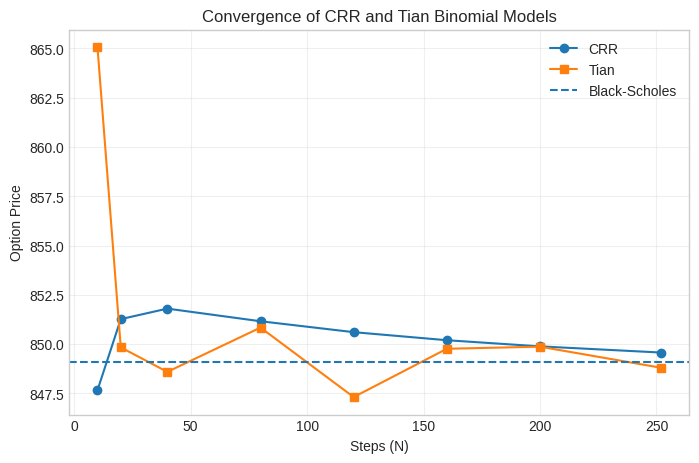

In [ ]:
# ================================
# UJI KONVERGENSI
# ================================

# jumlah step yang diuji
N_values = [10,20,40,80,120,160,200,252]

crr_prices = []
tian_prices = []

for N in N_values:

    crr_price = CRR_option(S0, K, r, sigma, T, N, "call", "european")
    tian_price = Tian_option(S0, K, r, sigma, T, N, "call", "european")

    crr_prices.append(crr_price)
    tian_prices.append(tian_price)

# Black-Scholes benchmark
bs_price = black_scholes(S0, K, r, sigma, T, "call")

# plot
plt.figure(figsize=(8,5))

plt.plot(N_values, crr_prices,
         marker='o',
         label="CRR")

plt.plot(N_values, tian_prices,
         marker='s',
         label="Tian")

plt.axhline(bs_price,
            linestyle="--",
            label="Black-Scholes")

plt.xlabel("Steps (N)")
plt.ylabel("Option Price")
plt.title("Convergence of CRR and Tian Binomial Models")
plt.legend()
plt.grid(alpha=0.3)

plt.show()